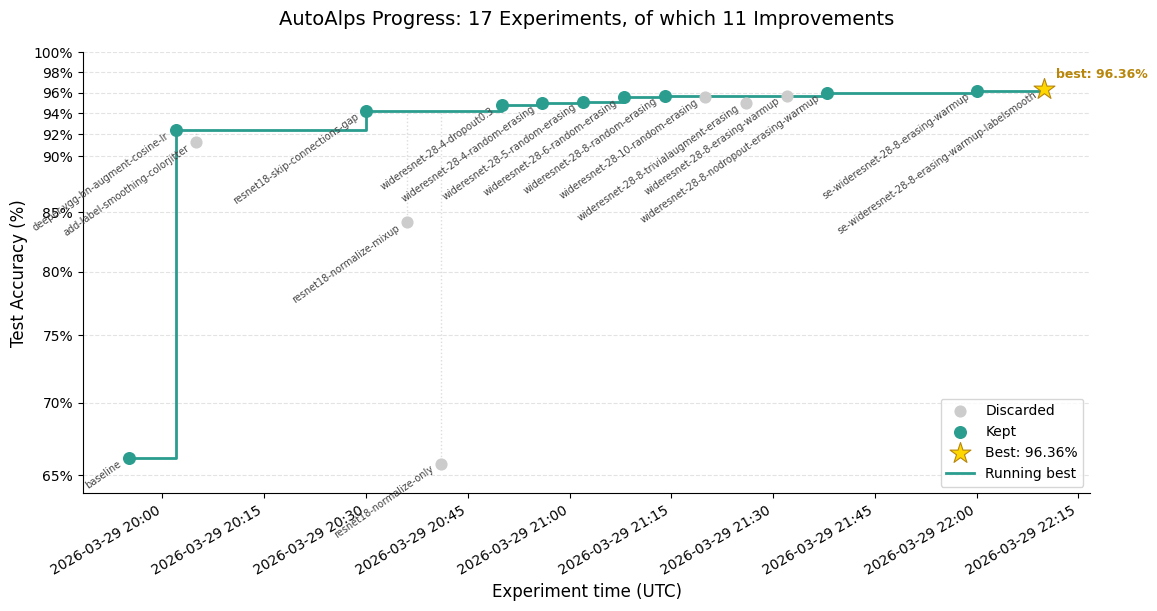

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.dates as mdates

df = pd.read_csv('results.tsv', sep='\t')
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
df = df.dropna(subset=['accuracy']).reset_index(drop=True)
df['exp_time'] = pd.to_datetime(df['datetime_utc'], utc=True)
df = df.sort_values('exp_time').reset_index(drop=True)
df['accuracy_pct'] = df['accuracy'] * 100
df['running_best'] = df['accuracy_pct'].cummax()
df['kept'] = df['accuracy_pct'] > df['accuracy_pct'].shift(1).cummax().fillna(0)
df.loc[0, 'kept'] = True

n_exps = len(df)
n_kept = df['kept'].sum()

best_idx = df['accuracy_pct'].idxmax()
best_row = df.loc[best_idx]

kept = df[df['kept'] & (df.index != best_idx)]
discarded = df[~df['kept']]

fig, ax = plt.subplots(figsize=(13, 7))

# Discarded
ax.scatter(discarded['exp_time'], discarded['accuracy_pct'],
           color='#cccccc', s=60, zorder=4, label='Discarded')

# Kept (excluding best)
ax.scatter(kept['exp_time'], kept['accuracy_pct'],
           color='#2a9d8f', s=70, zorder=5, label='Kept')

# Best result: yellow star
ax.scatter(best_row['exp_time'], best_row['accuracy_pct'],
           color='gold', s=250, marker='*', zorder=6, edgecolors='#b8860b', linewidths=0.8,
           label=f"Best: {best_row['accuracy_pct']:.2f}%")
ax.annotate(
    f"best: {best_row['accuracy_pct']:.2f}%",
    xy=(best_row['exp_time'], best_row['accuracy_pct']),
    xytext=(8, 6),
    textcoords='offset points',
    fontsize=9,
    fontweight='bold',
    color='#b8860b',
    va='bottom',
    ha='left',
)

# Running best step line
ax.step(df['exp_time'], df['running_best'],
        where='post', color='#2a9d8f', linewidth=2, zorder=2, label='Running best')

# Dotted drop lines
for _, row in df.iterrows():
    if row['accuracy_pct'] < row['running_best']:
        ax.plot([row['exp_time'], row['exp_time']],
                [row['accuracy_pct'], row['running_best']],
                color='#dddddd', linestyle=':', linewidth=1, zorder=1)

# Annotations: oblique, no line breaks, anchored at top-right of text (before/under point)
for _, row in df.iterrows():
    label = str(row['experiment_description'])
    ax.annotate(
        label,
        xy=(row['exp_time'], row['accuracy_pct']),
        xytext=(-8, 0),
        textcoords='offset points',
        fontsize=7,
        color='#444444',
        ha='right',
        va='top',
        rotation=35,
        rotation_mode='anchor',
    )

# Log y-axis, ticks formatted as %
ax.set_yscale('log')
y_min = df['accuracy_pct'].min() * 0.97
y_max = 100
ax.set_ylim(y_min, y_max)

tick_vals = [v for v in [50, 60, 65, 70, 75, 80, 85, 90, 92, 94, 96, 98, 100]
             if y_min <= v <= y_max]
ax.set_yticks(tick_vals)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_xlabel('Experiment time (UTC)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(f'AutoAlps Progress: {n_exps} Experiments, of which {n_kept} Improvements', fontsize=14, pad=20)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.25)
plt.savefig('progress.png', dpi=150)
plt.show()
